فایل: C:/Users/ImagingLAB/Desktop/پایان نامه نداف/اصلی پایان نامه/هسته انار/نمونه پوست.xlsx
شیت: Sheet1
θ: teta | I: int
g = sum(I cosθ) / sum(I)
  g(+زاویه) = 0.787134
  g(-زاویه) = 0.799412
  g(میانگین دو جهت) = 0.793273
Saved: C:/Users/ImagingLAB/Desktop/پایان نامه نداف/اصلی پایان نامه/هسته انار\نمونه پوست_raw.xlsx


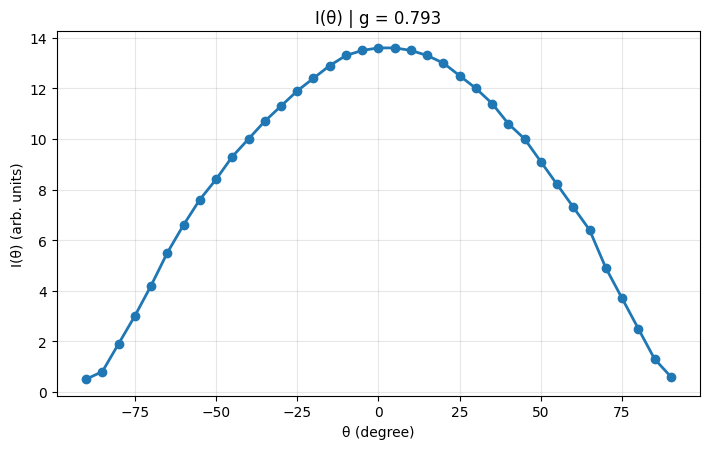

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import tkinter as tk
from tkinter import filedialog, messagebox
import matplotlib.pyplot as plt

def g_paper(theta_deg, I):
    th = np.asarray(theta_deg, dtype=float)
    I  = np.asarray(I, dtype=float)
    m = np.isfinite(th) & np.isfinite(I)
    th, I = th[m], I[m]
    if I.size == 0:
        raise ValueError("هیچ داده‌ی معتبری وجود ندارد.")
    m2 = (th >= -180) & (th <= 180)
    th, I = th[m2], I[m2]
    if np.nansum(I) == 0:
        raise ZeroDivisionError("مجموع شدت صفر است.")
    th_rad = np.deg2rad(th)
    return float(np.nansum(I * np.cos(th_rad)) / np.nansum(I))

def average_two_directions(theta_deg, I):
    th = np.asarray(theta_deg, dtype=float)
    I  = np.asarray(I, dtype=float)
    has_pos = np.any(th > 0)
    has_neg = np.any(th < 0)
    if has_pos and has_neg:
        g_pos = g_paper(th[th>=0], I[th>=0])
        g_neg = g_paper(th[th<=0], I[th<=0])
        return (g_pos + g_neg) / 2.0, g_pos, g_neg
    else:
        g_single = g_paper(th, I)
        return g_single, None, None

def choose_from_list(root, title, options):
    win = tk.Toplevel(root); win.title(title); win.resizable(False, False)
    lb = tk.Listbox(win, selectmode="browse", width=50,
                    height=min(15, max(5, len(options))))
    for opt in options: lb.insert(tk.END, opt)
    lb.grid(row=0, column=0, padx=10, pady=10, sticky="nsew")
    res = {"sel": None}
    def on_ok():
        sel = lb.curselection()
        if not sel:
            messagebox.showwarning("هشدار", "هیچ موردی انتخاب نشد."); return
        res["sel"] = options[sel[0]]; win.destroy()
    def on_cancel(): res["sel"]=None; win.destroy()
    btnf = tk.Frame(win); btnf.grid(row=1, column=0, pady=(0,10))
    tk.Button(btnf, text="تأیید", command=on_ok).pack(side="left", padx=5)
    tk.Button(btnf, text="لغو",  command=on_cancel).pack(side="left", padx=5)
    win.grab_set(); win.focus_force(); win.wait_window()
    return res["sel"]

def main():
    root = tk.Tk(); root.withdraw()
    messagebox.showinfo("انتخاب فایل", "لطفاً فایل اکسل (.xlsx/.xls) را انتخاب کنید.")
    fpath = filedialog.askopenfilename(
        title="انتخاب فایل اکسل",
        filetypes=[("Excel files", "*.xlsx *.xls"), ("All files", "*.*")]
    )
    if not fpath:
        messagebox.showwarning("لغو", "فایلی انتخاب نشد."); return

    try:
        xls = pd.ExcelFile(fpath)
    except Exception as e:
        messagebox.showerror("خطا در خواندن فایل", str(e)); return

    sheets = xls.sheet_names
    sh = sheets[0] if len(sheets)==1 else choose_from_list(root, "انتخاب شیت", sheets)
    if sh is None: return

    try:
        df = xls.parse(sh)
    except Exception as e:
        messagebox.showerror("خطا در خواندن شیت", str(e)); return
    if df.empty:
        messagebox.showerror("داده خالی", "شیت انتخابی داده‌ای ندارد."); return

    cols = list(df.columns)
    theta_col = choose_from_list(root, "ستون θ را انتخاب کنید", cols)
    if theta_col is None: return
    I_col     = choose_from_list(root, "ستون شدت I(θ) را انتخاب کنید", cols)
    if I_col is None: return

    theta_raw = pd.to_numeric(df[theta_col], errors="coerce")
    I_raw     = pd.to_numeric(df[I_col], errors="coerce")
    m_valid   = np.isfinite(theta_raw) & np.isfinite(I_raw)

    theta_valid = theta_raw[m_valid].to_numpy(float)
    I_valid     = I_raw[m_valid].to_numpy(float)

    # محاسبه g فقط با I خام
    try:
        g_avg, g_pos, g_neg = average_two_directions(theta_valid, I_valid)
    except Exception as e:
        messagebox.showerror("خطا در محاسبه g", str(e)); return

    txt = [f"فایل: {fpath}",
           f"شیت: {sh}",
           f"θ: {theta_col} | I: {I_col}",
           "g = sum(I cosθ) / sum(I)"]
    if g_pos is not None and g_neg is not None:
        txt += [f"  g(+زاویه) = {g_pos:.6f}",
                f"  g(-زاویه) = {g_neg:.6f}",
                f"  g(میانگین دو جهت) = {g_avg:.6f}"]
    else:
        txt.append(f"  g = {g_avg:.6f}  (تک‌جهته)")
    messagebox.showinfo("نتیجه g", "\n".join(txt))
    print("\n".join(txt))

    # خروجی اکسل: خام + cos(theta) + I_raw*cos(theta) + نوشتن g ها
    theta_rad_all = np.deg2rad(theta_raw.to_numpy(float))
    cos_theta_all = np.cos(theta_rad_all)
    df_out = pd.DataFrame({
        "theta_deg": theta_raw,
        "I_raw": I_raw,
        "cos_theta": cos_theta_all,
        "I_raw_cos": I_raw * cos_theta_all
    })

    base = os.path.splitext(os.path.basename(fpath))[0]
    out_dir = os.path.dirname(fpath)
    out_excel = os.path.join(out_dir, f"{base}_raw.xlsx")

    # شیت summary و همچنین درج مقادیر g در انتهای شیت داده‌ها
    summary_df = pd.DataFrame({
        "metric": ["g_pos", "g_neg", "g_avg"],
        "value":  [g_pos,   g_neg,   g_avg  ]
    })

    with pd.ExcelWriter(out_excel, engine="openpyxl") as writer:
        # 1) شیت داده‌ها
        df_out.to_excel(writer, index=False, sheet_name="raw_based")
        # 2) summary در شیت جدا
        summary_df.to_excel(writer, index=False, sheet_name="summary")

        # 3) همان gها در انتهای شیت داده‌ها (raw_based)
        ws = writer.sheets["raw_based"]
        start_row = len(df_out) + 2  # یک ردیف فاصله
        # هدر کوچک
        ws.cell(row=start_row,     column=1, value="metric")
        ws.cell(row=start_row,     column=2, value="value")
        # مقادیر
        ws.cell(row=start_row + 1, column=1, value="g_pos")
        ws.cell(row=start_row + 1, column=2, value=None if g_pos is None else float(g_pos))
        ws.cell(row=start_row + 2, column=1, value="g_neg")
        ws.cell(row=start_row + 2, column=2, value=None if g_neg is None else float(g_neg))
        ws.cell(row=start_row + 3, column=1, value="g_avg")
        ws.cell(row=start_row + 3, column=2, value=float(g_avg))

    print(f"Saved: {out_excel}")

    # نمودار با I خام
    order = np.argsort(theta_valid)
    plt.figure(figsize=(7.2,4.6))
    plt.plot(theta_valid[order], I_valid[order], "o-", linewidth=2)
    plt.xlabel("θ (degree)"); plt.ylabel("I(θ) (arb. units)")
    plt.title(f"I(θ) | g = {g_avg:.3f}")
    plt.grid(True, alpha=0.3); plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{base}.png")
    try:
        plt.savefig(fig_path, dpi=200)
    except Exception:
        pass
    plt.show()

if __name__ == "__main__":
    main()

